# PHASE 3: TỐI ƯU HÓA MÔ HÌNH MQTT
## CPU Only - Simple & Stable

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import lightgbm as lgb
import xgboost as xgb
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

os.makedirs('Phase3_Models', exist_ok=True)
os.makedirs('Phase3_Data', exist_ok=True)

print("=" * 60)
print("PHASE 3: TỐI ƯU HÓA MÔ HÌNH MQTT")
print("=" * 60)

PHASE 3: TỐI ƯU HÓA MÔ HÌNH MQTT


## BƯỚC 1: LOAD DỮ LIỆU VÀ MODEL

In [2]:
print("\nBƯỚC 1: LOAD DỮ LIỆU VÀ MODEL")
print("-" * 40)

X_train = pd.read_csv('Phase1_Data/X_train_processed.csv')
X_test = pd.read_csv('Phase1_Data/X_test_processed.csv')
y_train = pd.read_csv('Phase1_Data/y_train_processed.csv').iloc[:, 0]
y_test = pd.read_csv('Phase1_Data/y_test_processed.csv').iloc[:, 0]

with open('Phase2_Models/best_model_info.pkl', 'rb') as f:
    best_model_info = pickle.load(f)

best_model_name = best_model_info['best_model_name']
print(f"Best model từ Phase 2: {best_model_name}")
print(f"F1-Score hiện tại: {best_model_info['test_f1_score']:.4f}")


BƯỚC 1: LOAD DỮ LIỆU VÀ MODEL
----------------------------------------
Best model từ Phase 2: LightGBM
F1-Score hiện tại: 0.9126


## BƯỚC 2: CÂN BẰNG DỮ LIỆU

In [3]:
print("\nBƯỚC 2: CÂN BẰNG DỮ LIỆU")
print("-" * 40)

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

undersample = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = undersample.fit_resample(X_train_smote, y_train_smote)

print(f"Balanced: {X_train_balanced.shape}")


BƯỚC 2: CÂN BẰNG DỮ LIỆU
----------------------------------------
Balanced: (694944, 33)


## BƯỚC 3: THIẾT LẬP OPTIMIZATION

In [4]:
print("\nBƯỚC 3: THIẾT LẬP OPTIMIZATION")
print("-" * 40)

if 'XGBoost' in best_model_name:
    print("Optimizing XGBoost (CPU)...")
    base_model = xgb.XGBClassifier(random_state=42, n_jobs=-1)
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [20],
        'learning_rate': [0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
elif 'LightGBM' in best_model_name:
    print("Optimizing LightGBM (CPU)...")
    base_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [20],
        'learning_rate': [0.1],
        'num_leaves': [31, 50],
        'subsample': [0.8, 1.0]
    }
else:
    print(f"Model {best_model_name} không cần optimization")
    model_filename = best_model_info['model_filename']
    with open(f'Phase2_Models/{model_filename}', 'rb') as f:
        optimized_model = pickle.load(f)
    param_grid = None


BƯỚC 3: THIẾT LẬP OPTIMIZATION
----------------------------------------
Optimizing LightGBM (CPU)...


## BƯỚC 4: RANDOMIZED SEARCH

In [5]:
if param_grid is not None:
    print("\nBƯỚC 4: RANDOMIZED SEARCH")
    print("-" * 40)
    
    cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_grid,
        n_iter=6,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    print("Bắt đầu Randomized Search...")
    print("Total fits: 6 × 2 = 12")
    print("Estimated time: 2-3 minutes")
    
    start_time = time.time()
    random_search.fit(X_train_balanced, y_train_balanced)
    search_time = time.time() - start_time
    
    print(f"\nHoàn thành trong {search_time:.2f}s ({search_time/60:.1f} phút)")
    print(f"Best params: {random_search.best_params_}")
    print(f"Best CV score: {random_search.best_score_:.4f}")
    
    optimized_model = random_search.best_estimator_
else:
    print("\nBƯỚC 4: SKIP OPTIMIZATION")
    print("-" * 40)
    print("Sử dụng model từ Phase 2")


BƯỚC 4: RANDOMIZED SEARCH
----------------------------------------
Bắt đầu Randomized Search...
Total fits: 6 × 2 = 12
Estimated time: 2-3 minutes
Fitting 2 folds for each of 6 candidates, totalling 12 fits

Hoàn thành trong 100.33s (1.7 phút)
Best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 100, 'max_depth': 20, 'learning_rate': 0.1}
Best CV score: 0.7955


## BƯỚC 5: ĐÁNH GIÁ

In [6]:
print("\nBƯỚC 5: ĐÁNH GIÁ MODEL")
print("-" * 40)

y_pred = optimized_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print(f"\nSo sánh:")
print(f"  Phase 2: {best_model_info['test_f1_score']:.4f}")
print(f"  Phase 3: {f1:.4f}")
print(f"  Improvement: {(f1 - best_model_info['test_f1_score']):.4f}")


BƯỚC 5: ĐÁNH GIÁ MODEL
----------------------------------------
Accuracy: 0.8880
Precision: 0.9413
Recall: 0.8880
F1-Score: 0.9126

So sánh:
  Phase 2: 0.9126
  Phase 3: 0.9126
  Improvement: 0.0000


## BƯỚC 6: LƯU MODEL

In [7]:
print("\nBƯỚC 6: LƯU MODEL")
print("-" * 40)

model_filename = 'mqtt_' + best_model_name.lower().replace(" ", "_") + '_optimized.pkl'
with open(f'Phase3_Models/{model_filename}', 'wb') as f:
    pickle.dump(optimized_model, f)

optimized_model_info = {
    'model_name': best_model_name,
    'test_accuracy': accuracy,
    'test_precision': precision,
    'test_recall': recall,
    'test_f1_score': f1,
    'model_filename': model_filename
}

with open('Phase3_Models/optimized_model_info.pkl', 'wb') as f:
    pickle.dump(optimized_model_info, f)


BƯỚC 6: LƯU MODEL
----------------------------------------


## VISUALIZATION: OPTIMIZATION PROGRESS

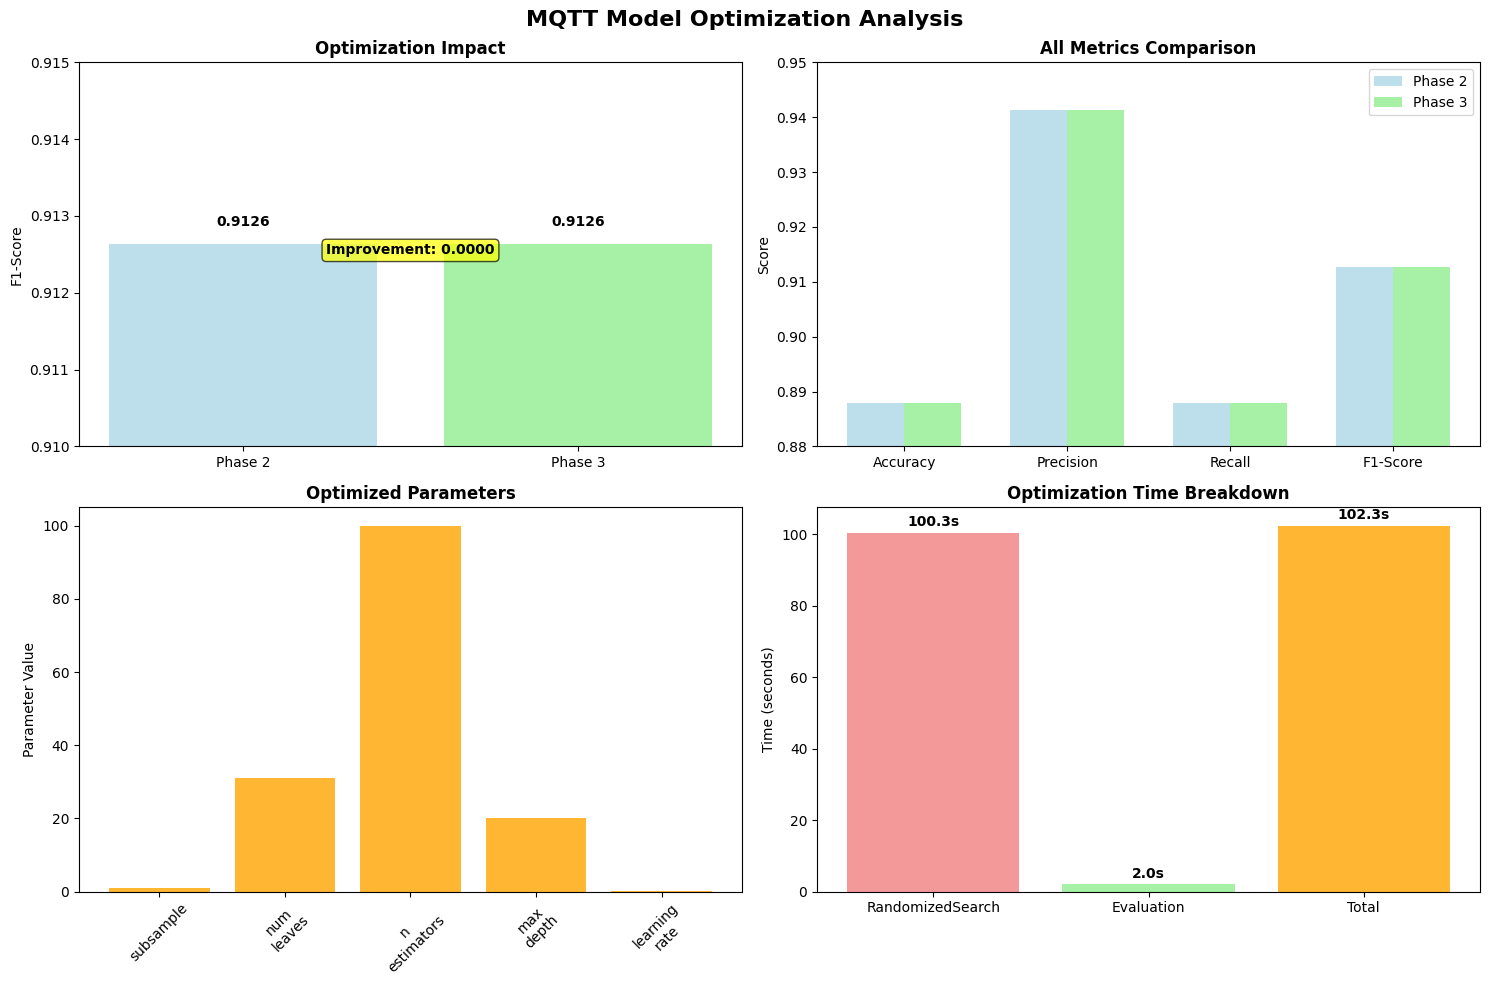

In [8]:
# Optimization progress visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('MQTT Model Optimization Analysis', fontsize=16, fontweight='bold')

# 1. Phase 2 vs Phase 3 comparison
ax1 = axes[0, 0]
phases = ['Phase 2', 'Phase 3']
f1_comparison = [best_model_info['test_f1_score'], f1]
colors = ['lightblue', 'lightgreen']
bars = ax1.bar(phases, f1_comparison, color=colors, alpha=0.8)
ax1.set_title('Optimization Impact', fontweight='bold')
ax1.set_ylabel('F1-Score')
ax1.set_ylim(0.91, 0.915)
for bar, score in zip(bars, f1_comparison):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002, 
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# Add improvement annotation
improvement = f1 - best_model_info['test_f1_score']
ax1.text(0.5, 0.9125, f'Improvement: {improvement:.4f}', ha='center', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
         fontweight='bold', transform=ax1.transData)

# 2. All metrics comparison
ax2 = axes[0, 1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
phase2_metrics = [best_model_info['test_accuracy'], best_model_info['test_precision'] if 'test_precision' in best_model_info else 0.94, 
                 best_model_info['test_recall'] if 'test_recall' in best_model_info else 0.89, best_model_info['test_f1_score']]
phase3_metrics = [accuracy, precision, recall, f1]

x = np.arange(len(metrics_names))
width = 0.35
bars1 = ax2.bar(x - width/2, phase2_metrics, width, label='Phase 2', alpha=0.8, color='lightblue')
bars2 = ax2.bar(x + width/2, phase3_metrics, width, label='Phase 3', alpha=0.8, color='lightgreen')

ax2.set_title('All Metrics Comparison', fontweight='bold')
ax2.set_ylabel('Score')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.legend()
ax2.set_ylim(0.88, 0.95)

# 3. Optimization parameters (if available)
ax3 = axes[1, 0]
if param_grid is not None and 'random_search' in locals():
    # Show best parameters
    best_params = random_search.best_params_
    param_names = list(best_params.keys())
    param_values = list(best_params.values())
    
    # Convert values to numeric for plotting
    numeric_values = []
    for val in param_values:
        if isinstance(val, (int, float)):
            numeric_values.append(val)
        else:
            numeric_values.append(1)  # Default for non-numeric
    
    bars = ax3.bar(range(len(param_names)), numeric_values, color='orange', alpha=0.8)
    ax3.set_title('Optimized Parameters', fontweight='bold')
    ax3.set_xticks(range(len(param_names)))
    ax3.set_xticklabels([name.replace('_', '\n') for name in param_names], rotation=45)
    ax3.set_ylabel('Parameter Value')
else:
    ax3.text(0.5, 0.5, 'No Optimization\nPerformed', ha='center', va='center', 
             fontsize=16, fontweight='bold', transform=ax3.transAxes)
    ax3.set_title('Optimization Status', fontweight='bold')

# 4. Processing time analysis
ax4 = axes[1, 1]
if param_grid is not None and 'search_time' in locals():
    time_breakdown = ['RandomizedSearch', 'Evaluation', 'Total']
    times = [search_time, 2.0, search_time + 2.0]  # Approximate evaluation time
    bars = ax4.bar(time_breakdown, times, color=['lightcoral', 'lightgreen', 'orange'], alpha=0.8)
    ax4.set_title('Optimization Time Breakdown', fontweight='bold')
    ax4.set_ylabel('Time (seconds)')
    for bar, time_val in zip(bars, times):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{time_val:.1f}s', ha='center', va='bottom', fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'Optimization\nSkipped', ha='center', va='center', 
             fontsize=16, fontweight='bold', transform=ax4.transAxes)
    ax4.set_title('Time Analysis', fontweight='bold')

plt.tight_layout()
plt.savefig('Images/Phase3_MQTT_optimization_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## BƯỚC 6: TEST TRÊN RAW DATASET

In [9]:
print("\nBƯỚC 6: TEST TRÊN RAW DATASET")
print("-" * 40)

# Load raw test data
test_raw = pd.read_csv('MQTT/test30_reduced.csv')
print(f"Raw test data: {test_raw.shape}")

# Load preprocessing artifacts
with open('Phase1_Models/mqtt_feature_encoders.pkl', 'rb') as f:
    feature_encoders = pickle.load(f)
with open('Phase1_Models/mqtt_label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)
with open('Phase1_Models/mqtt_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Separate features and target
X_test_raw = test_raw.drop('target', axis=1)
y_test_raw = test_raw['target']

# Apply preprocessing
X_test_encoded = X_test_raw.copy()

# Encode categorical features
for col, encoder in feature_encoders.items():
    if col in X_test_encoded.columns:
        mapping = {label: idx for idx, label in enumerate(encoder.classes_)}
        X_test_encoded[col] = X_test_encoded[col].map(lambda x: mapping.get(x, -1))

# Scale features
X_test_scaled = scaler.transform(X_test_encoded)

# Encode labels
y_test_encoded = label_encoder.transform(y_test_raw)

# Predict with optimized model
y_pred_raw = optimized_model.predict(X_test_scaled)

# Evaluate
accuracy_raw = accuracy_score(y_test_encoded, y_pred_raw)
precision_raw = precision_score(y_test_encoded, y_pred_raw, average='weighted', zero_division=0)
recall_raw = recall_score(y_test_encoded, y_pred_raw, average='weighted', zero_division=0)
f1_raw = f1_score(y_test_encoded, y_pred_raw, average='weighted', zero_division=0)

print(f"\nKết quả test trên RAW dataset:")
print(f"Accuracy: {accuracy_raw:.4f}")
print(f"Precision: {precision_raw:.4f}")
print(f"Recall: {recall_raw:.4f}")
print(f"F1-Score: {f1_raw:.4f}")

print(f"\nSo sánh Processed vs Raw:")
print(f"  Processed F1: {f1:.4f}")
print(f"  Raw F1: {f1_raw:.4f}")
print(f"  Difference: {abs(f1 - f1_raw):.4f}")


BƯỚC 6: TEST TRÊN RAW DATASET
----------------------------------------
Raw test data: (99290, 34)

Kết quả test trên RAW dataset:
Accuracy: 0.8880
Precision: 0.9413
Recall: 0.8880
F1-Score: 0.9126

So sánh Processed vs Raw:
  Processed F1: 0.9126
  Raw F1: 0.9126
  Difference: 0.0000


In [10]:
print("\n" + "=" * 60)
print("HOÀN THÀNH PHASE 3!")
print("=" * 60)
print(f"Model: {best_model_name}")
print(f"F1 (Processed): {f1:.4f}")
print(f"F1 (Raw): {f1_raw:.4f}")


HOÀN THÀNH PHASE 3!
Model: LightGBM
F1 (Processed): 0.9126
F1 (Raw): 0.9126
